1)Product Feature Discussion Analysis

Frequently Discussed Product Features:

battery : 4
camera : 4
price : 3
delivery : 3
packaging : 3
backup : 1
lens : 1
charging : 1
resolution : 1


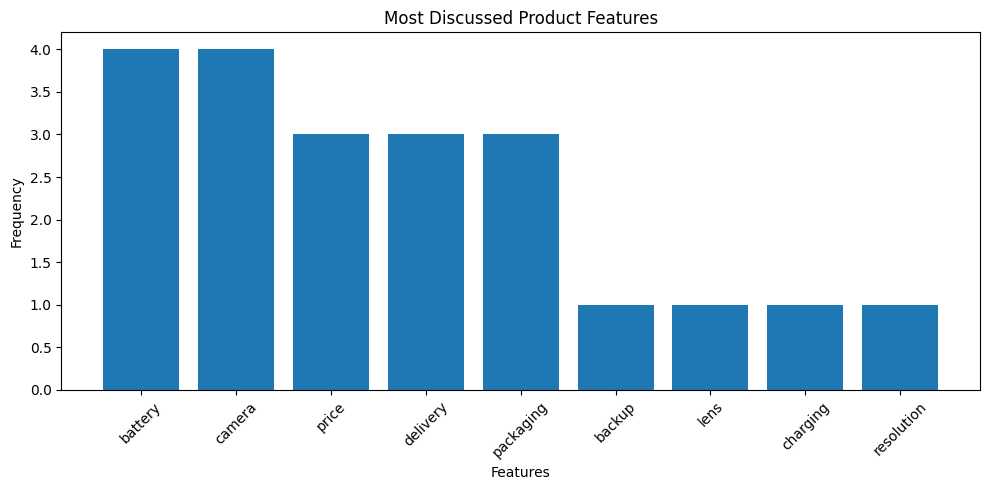


Most Important Feature to Customers:
battery with 4 mentions


In [4]:
# Product Feature Discussion Analysis
# Install if needed:
# pip install spacy matplotlib
# python -m spacy download en_core_web_sm

import spacy
from collections import Counter
import matplotlib.pyplot as plt

# Load NLP model
nlp = spacy.load("en_core_web_sm")

# ----------------------------------------
# Sample Customer Reviews
# ----------------------------------------

reviews = [
    "The battery life of this phone is amazing.",
    "Camera quality is excellent but price is high.",
    "Delivery time was very slow.",
    "Packaging was damaged during shipping.",
    "Battery drains too quickly.",
    "Camera performance in low light is poor.",
    "Price is affordable and worth it.",
    "Fast delivery and great packaging.",
    "Battery backup is strong.",
    "Camera lens quality is superb.",
    "Packaging looks premium.",
    "Delivery was delayed by two days.",
    "Price is too expensive.",
    "Battery charging speed is excellent.",
    "Camera resolution is fantastic."
]

# ----------------------------------------
# Product Features to Track
# ----------------------------------------

features = [
    "battery", "camera", "price",
    "packaging", "delivery",
    "charging", "resolution",
    "lens", "backup"
]

# ----------------------------------------
# NLP Pipeline
# ----------------------------------------

feature_count = Counter()

for review in reviews:
    doc = nlp(review.lower())

    for token in doc:
        if token.text in features:
            feature_count[token.text] += 1

# ----------------------------------------
# Print Results
# ----------------------------------------

print("Frequently Discussed Product Features:\n")

for feature, count in feature_count.most_common():
    print(feature, ":", count)

# ----------------------------------------
# Bar Chart
# ----------------------------------------

labels = list(feature_count.keys())
counts = list(feature_count.values())

plt.figure(figsize=(10,5))
plt.bar(labels, counts)
plt.title("Most Discussed Product Features")
plt.xlabel("Features")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------------------------
# Final Insight
# ----------------------------------------

top_feature = feature_count.most_common(1)[0]

print("\nMost Important Feature to Customers:")
print(top_feature[0], "with", top_feature[1], "mentions")

2) Word Frequency Analysis from Uploaded Text

In [6]:
# Word Frequency Analysis from Hyperlink (URL)
# Install if needed:
# pip install requests beautifulsoup4 matplotlib

import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import string
from collections import Counter

# -----------------------------------
# Step 1: Enter Hyperlink
# -----------------------------------

url = input("Enter webpage URL: ")

# -----------------------------------
# Step 2: Fetch Webpage Content
# -----------------------------------

response = requests.get(url)
html = response.text

# Parse HTML
soup = BeautifulSoup(html, "html.parser")

# Extract visible text
text = soup.get_text()

# -----------------------------------
# Step 3: Preprocess Text
# -----------------------------------

# Convert to lowercase
text = text.lower()

# Remove punctuation
text = text.translate(str.maketrans('', '', string.punctuation))

# Split into words
words = text.split()

# Optional: remove short words
words = [word for word in words if len(word) > 2]

# -----------------------------------
# Step 4: Compute Word Frequency
# -----------------------------------

word_freq = Counter(words)

# Top 10 frequent words
top_words = word_freq.most_common(10)

labels = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

# -----------------------------------
# Plot 1: Bar Chart
# -----------------------------------

plt.figure(figsize=(10,5))
plt.bar(labels, counts)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------------
# Plot 2: Histogram
# -----------------------------------

plt.figure(figsize=(8,5))
plt.hist(list(word_freq.values()), bins=10, edgecolor='black')
plt.title("Distribution of Word Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

# -----------------------------------
# Plot 3: Pie Chart
# -----------------------------------

plt.figure(figsize=(8,8))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Proportion of Most Frequent Words")
plt.tight_layout()
plt.show()

KeyboardInterrupt: Interrupted by user

3)Bag of Words Representation from User Text

Generated Vocabulary and Word Counts:

           Word  Count
4       battery      3
5        camera      3
25        price      2
6      charging      2
10     delivery      2
12    excellent      2
13         fast      2
22        phone      2
20    packaging      2
26      quality      2
0    affordable      1
2       average      1
9       damaged      1
8   competitors      1
7      compared      1
3        backup      1
1       amazing      1
16         lens      1
15         high      1
14         good      1
11       drains      1
19          low      1
21  performance      1
18        light      1
17         life      1
24         poor      1
23       photos      1
27      quickly      1
28   reasonable      1
29        sharp      1
30        speed      1
31       strong      1
32       update      1


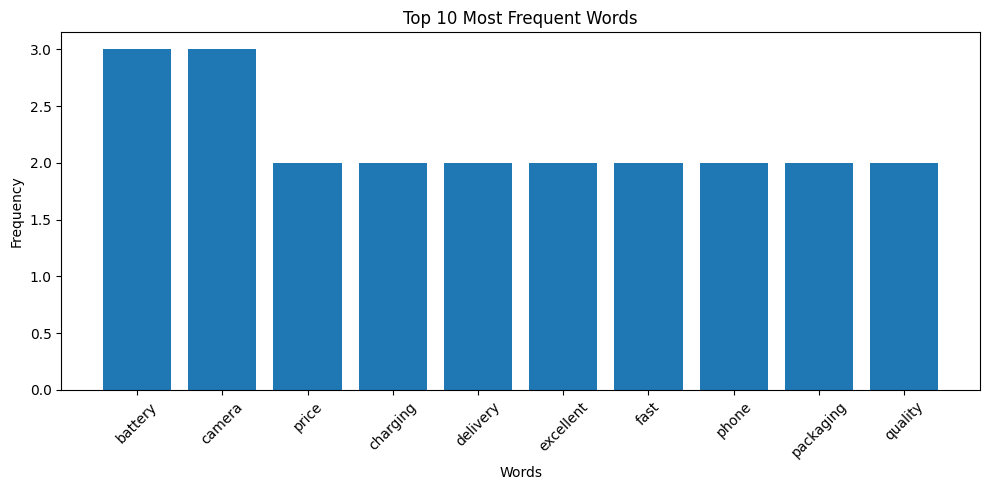

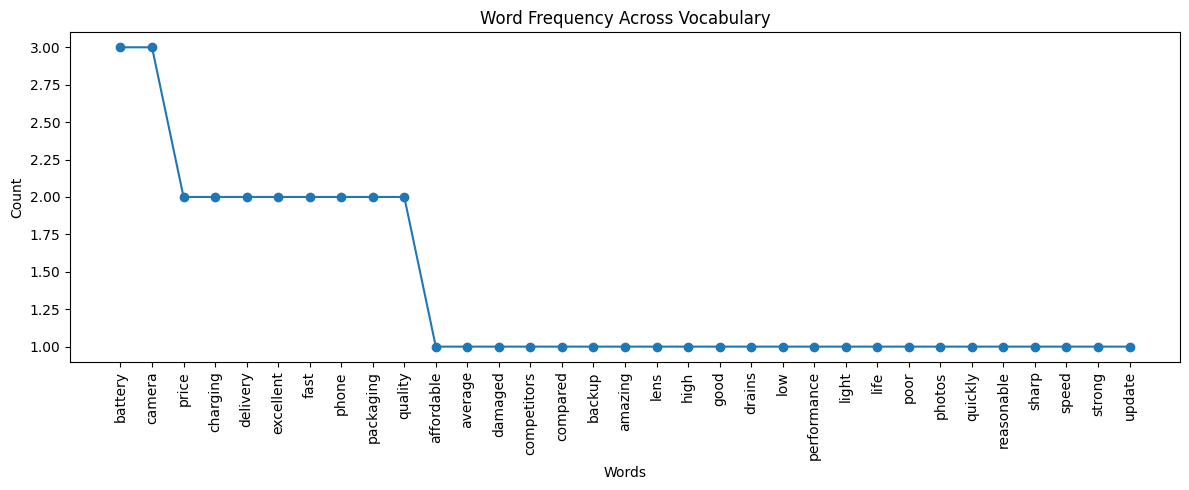

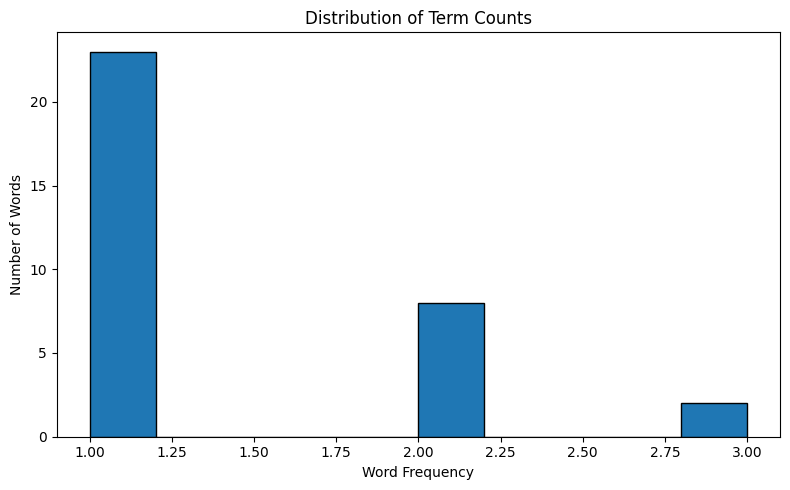

In [5]:
# Bag of Words Representation using Sample Data
# Install if needed:
# pip install scikit-learn matplotlib pandas

import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# -----------------------------------
# Step 1: Sample Text Data
# -----------------------------------

text = """
The phone has excellent battery life and fast charging.
Camera quality is amazing and photos are sharp.
Battery backup is strong but charging speed is average.
The price of the phone is reasonable and affordable.
Delivery was fast and packaging was good.
Camera performance in low light is poor.
Battery drains quickly after update.
Packaging was damaged during delivery.
Price is too high compared to competitors.
The camera lens quality is excellent.
"""

# -----------------------------------
# Step 2: Split into Sentences
# -----------------------------------

documents = re.split(r'[.!?]+', text)
documents = [doc.strip() for doc in documents if doc.strip()]

# -----------------------------------
# Step 3: Apply Bag of Words Model
# -----------------------------------

vectorizer = CountVectorizer(lowercase=True, stop_words='english')

X = vectorizer.fit_transform(documents)

# Vocabulary
vocab = vectorizer.get_feature_names_out()

# Word Counts
word_counts = X.toarray().sum(axis=0)

# Create DataFrame
df = pd.DataFrame({
    "Word": vocab,
    "Count": word_counts
})

# Sort descending
df = df.sort_values(by="Count", ascending=False)

# -----------------------------------
# Step 4: Display Vocabulary and Counts
# -----------------------------------

print("Generated Vocabulary and Word Counts:\n")
print(df)

# -----------------------------------
# Plot 1: Bar Plot (Top 10 Words)
# -----------------------------------

top10 = df.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Word"], top10["Count"])
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------------
# Plot 2: Line Plot
# -----------------------------------

plt.figure(figsize=(12,5))
plt.plot(df["Word"], df["Count"], marker='o')
plt.title("Word Frequency Across Vocabulary")
plt.xlabel("Words")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# -----------------------------------
# Plot 3: Histogram
# -----------------------------------

plt.figure(figsize=(8,5))
plt.hist(df["Count"], bins=10, edgecolor='black')
plt.title("Distribution of Term Counts")
plt.xlabel("Word Frequency")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()


4)Document-Term Matrix Visualization

Document-Term Matrix:

        affordable  amazing  average  backup  battery  camera  charging  \
Doc 1            0        0        0       0        1       0         1   
Doc 2            0        1        0       0        0       1         0   
Doc 3            0        0        1       1        1       0         1   
Doc 4            1        0        0       0        0       0         0   
Doc 5            0        0        0       0        0       0         0   
Doc 6            0        0        0       0        0       1         0   
Doc 7            0        0        0       0        1       0         0   
Doc 8            0        0        0       0        0       0         0   
Doc 9            0        0        0       0        0       0         0   
Doc 10           0        0        0       0        0       1         0   

        compared  competitors  damaged  ...  poor  price  quality  quickly  \
Doc 1          0            0        0  ...     0      0        0        

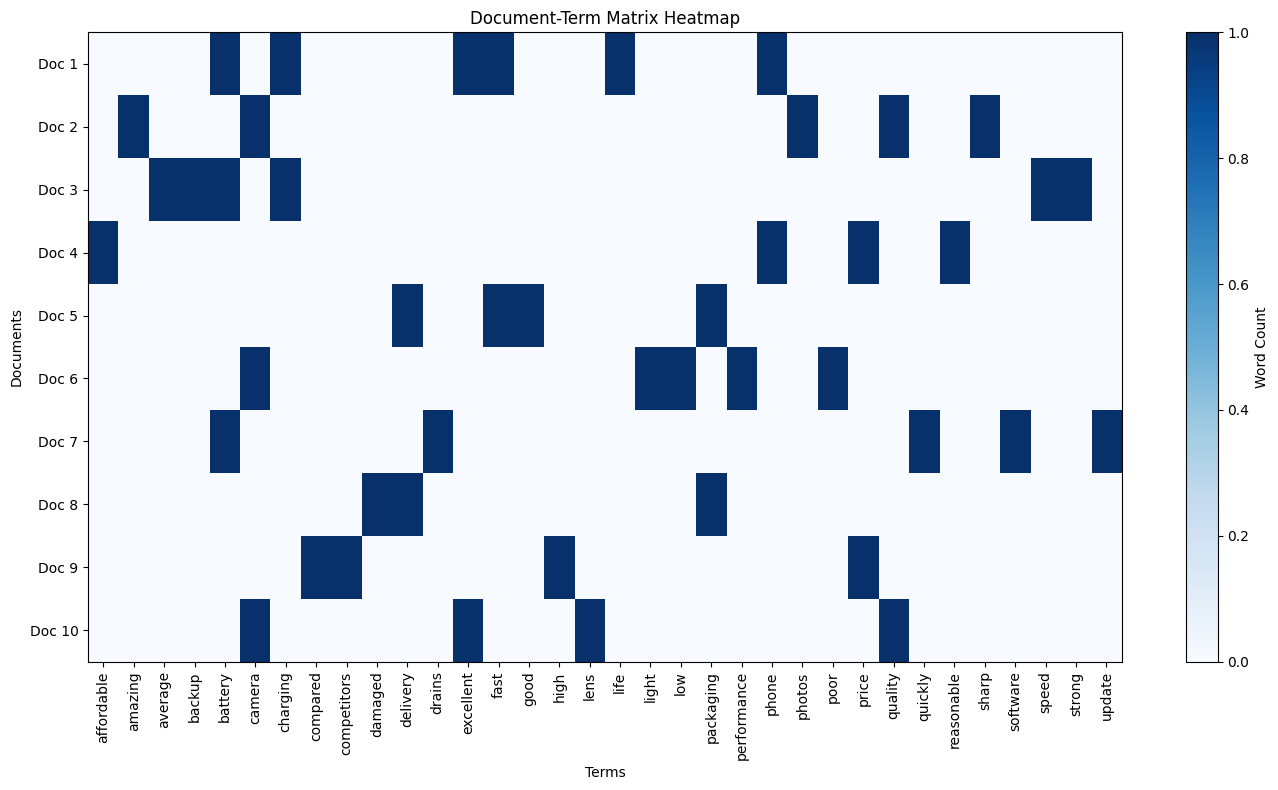

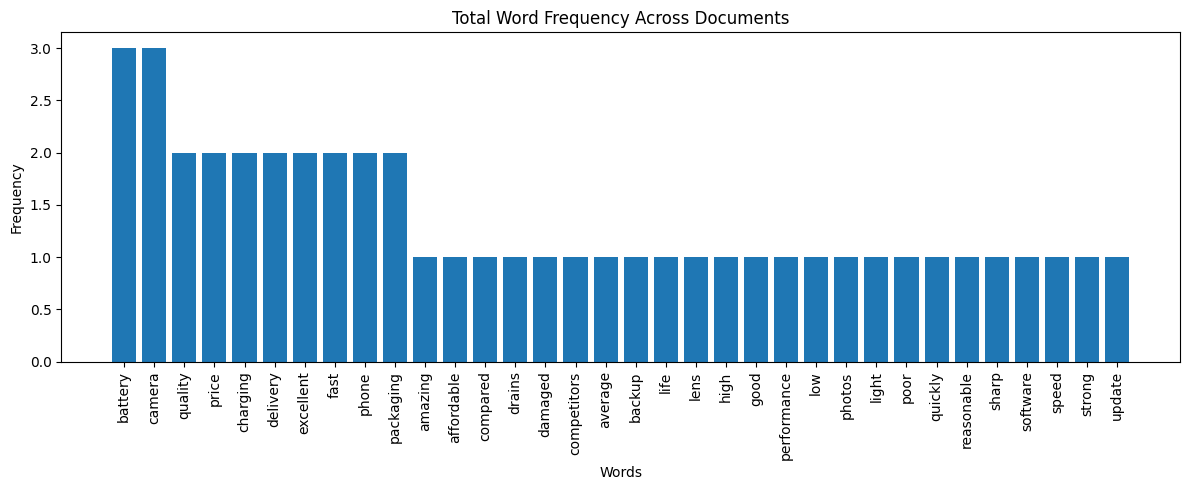

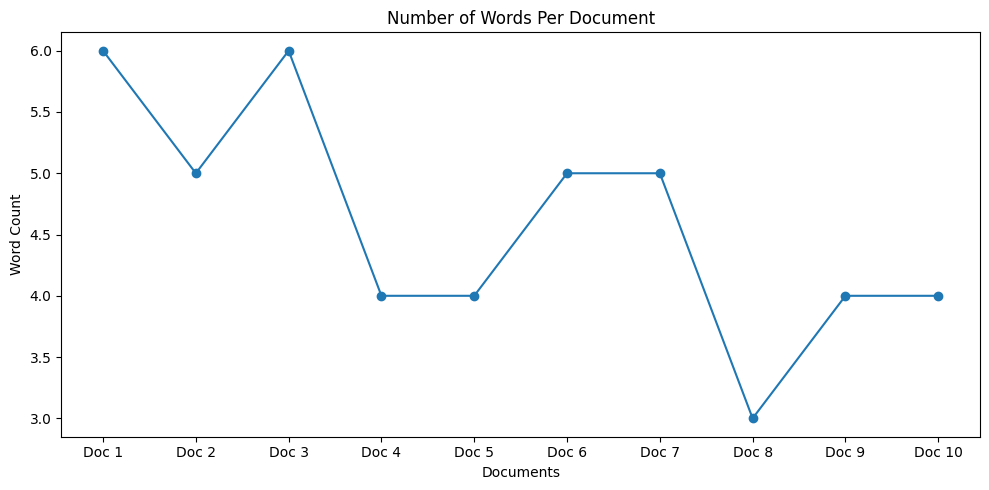

In [7]:
# Document-Term Matrix Visualization using Sample Data
# Install if needed:
# pip install scikit-learn pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# -----------------------------------
# Step 1: Sample Documents
# -----------------------------------

documents = [
    "The phone has excellent battery life and fast charging",
    "Camera quality is amazing and photos are sharp",
    "Battery backup is strong but charging speed is average",
    "The price of the phone is affordable and reasonable",
    "Delivery was fast and packaging was good",
    "Camera performance in low light is poor",
    "Battery drains quickly after software update",
    "Packaging was damaged during delivery",
    "Price is too high compared to competitors",
    "The camera lens quality is excellent"
]

# -----------------------------------
# Step 2: Create Document-Term Matrix
# -----------------------------------

vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english'
)

X = vectorizer.fit_transform(documents)

# -----------------------------------
# Step 3: Convert to DataFrame
# -----------------------------------

terms = vectorizer.get_feature_names_out()

dtm = pd.DataFrame(
    X.toarray(),
    columns=terms,
    index=[f"Doc {i+1}" for i in range(len(documents))]
)

print("Document-Term Matrix:\n")
print(dtm)

# -----------------------------------
# Plot 1: Heatmap Style Matrix Visualization
# -----------------------------------

plt.figure(figsize=(14,8))
plt.imshow(dtm, aspect='auto', cmap='Blues')
plt.colorbar(label="Word Count")
plt.title("Document-Term Matrix Heatmap")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.xticks(range(len(terms)), terms, rotation=90)
plt.yticks(range(len(dtm.index)), dtm.index)
plt.tight_layout()
plt.show()

# -----------------------------------
# Plot 2: Bar Chart - Total Word Frequency
# -----------------------------------

word_totals = dtm.sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(12,5))
plt.bar(word_totals.index, word_totals.values)
plt.title("Total Word Frequency Across Documents")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# -----------------------------------
# Plot 3: Line Plot - Words Per Document
# -----------------------------------

words_per_doc = dtm.sum(axis=1)

plt.figure(figsize=(10,5))
plt.plot(dtm.index, words_per_doc.values, marker='o')
plt.title("Number of Words Per Document")
plt.xlabel("Documents")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()


5)Healthcare Chatbot

In [10]:
from IPython.display import HTML

html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Medi - Health Assistant</title>
<link href="https://fonts.googleapis.com/css2?family=Fraunces:ital,wght@0,300;0,400;0,500;1,300;1,400&family=Instrument+Sans:wght@300;400;500&display=swap" rel="stylesheet">
<style>
  :root {
    --bg: #f5f7f4;
    --white: #ffffff;
    --surface: #eef1ed;
    --sage: #4a7c5e;
    --sage-light: #6a9e7e;
    --sage-pale: #d4e4db;
    --sage-xpale: #eaf2ee;
    --teal: #2d6a6a;
    --text: #1e2b24;
    --text-mid: #4a5e52;
    --text-dim: #8ea598;
    --border: #dde7e1;
    --warning: #c47b2e;
    --warning-bg: #fdf4ea;
    --red: #b94040;
  }

  * { margin: 0; padding: 0; box-sizing: border-box; }

  body {
    background: var(--bg);
    color: var(--text);
    font-family: 'Instrument Sans', sans-serif;
    height: 100vh;
    display: flex;
    flex-direction: column;
    overflow: hidden;
  }

  /* Subtle organic background */
  body::before {
    content: '';
    position: fixed;
    inset: 0;
    background:
      radial-gradient(ellipse 800px 600px at 10% 20%, rgba(74,124,94,0.06) 0%, transparent 60%),
      radial-gradient(ellipse 600px 500px at 90% 80%, rgba(45,106,106,0.05) 0%, transparent 60%);
    pointer-events: none;
    z-index: 0;
  }

  /* HEADER */
  header {
    position: relative;
    z-index: 10;
    background: var(--white);
    border-bottom: 1px solid var(--border);
    padding: 14px 24px;
    display: flex;
    align-items: center;
    gap: 14px;
    box-shadow: 0 1px 12px rgba(74,124,94,0.06);
    flex-shrink: 0;
  }

  .logo-mark {
    width: 40px;
    height: 40px;
    background: linear-gradient(135deg, var(--sage), var(--teal));
    border-radius: 12px;
    display: flex;
    align-items: center;
    justify-content: center;
    font-size: 20px;
    flex-shrink: 0;
    box-shadow: 0 4px 12px rgba(74,124,94,0.25);
  }

  .brand { flex: 1; }

  .brand-name {
    font-family: 'Fraunces', serif;
    font-size: 22px;
    font-weight: 500;
    color: var(--sage);
    letter-spacing: -0.3px;
    line-height: 1;
  }

  .brand-tagline {
    font-size: 11px;
    color: var(--text-dim);
    letter-spacing: 0.5px;
    margin-top: 2px;
    font-weight: 300;
  }

  .online-badge {
    display: flex;
    align-items: center;
    gap: 6px;
    font-size: 12px;
    color: var(--sage);
    background: var(--sage-xpale);
    border: 1px solid var(--sage-pale);
    padding: 5px 12px;
    border-radius: 20px;
    font-weight: 400;
  }

  .online-dot {
    width: 7px;
    height: 7px;
    background: var(--sage-light);
    border-radius: 50%;
    animation: breathe 2.5s ease-in-out infinite;
  }

  @keyframes breathe {
    0%, 100% { transform: scale(1); opacity: 1; }
    50% { transform: scale(1.3); opacity: 0.6; }
  }

  /* DISCLAIMER BANNER */
  .disclaimer {
    position: relative;
    z-index: 9;
    background: var(--warning-bg);
    border-bottom: 1px solid #e8c99a;
    padding: 8px 24px;
    display: flex;
    align-items: center;
    gap: 8px;
    font-size: 11.5px;
    color: var(--warning);
    font-weight: 400;
    flex-shrink: 0;
  }

  .disclaimer span { font-size: 13px; }

  /* CHAT AREA */
  .chat-container {
    flex: 1;
    overflow-y: auto;
    padding: 24px 20px;
    display: flex;
    flex-direction: column;
    gap: 18px;
    position: relative;
    z-index: 5;
    scrollbar-width: thin;
    scrollbar-color: var(--border) transparent;
  }

  .chat-container::-webkit-scrollbar { width: 4px; }
  .chat-container::-webkit-scrollbar-thumb { background: var(--border); border-radius: 4px; }

  /* Welcome */
  .welcome {
    display: flex;
    flex-direction: column;
    align-items: center;
    text-align: center;
    padding: 32px 20px 20px;
    gap: 20px;
    animation: rise 0.6s cubic-bezier(0.16,1,0.3,1) both;
  }

  @keyframes rise {
    from { opacity: 0; transform: translateY(24px); }
    to { opacity: 1; transform: translateY(0); }
  }

  .pulse-ring {
    width: 72px;
    height: 72px;
    position: relative;
    display: flex;
    align-items: center;
    justify-content: center;
  }

  .pulse-ring::before, .pulse-ring::after {
    content: '';
    position: absolute;
    border-radius: 50%;
    border: 1.5px solid var(--sage-pale);
    animation: ringPulse 2.5s ease-out infinite;
  }

  .pulse-ring::after { animation-delay: 1.25s; }

  @keyframes ringPulse {
    0% { width: 48px; height: 48px; opacity: 1; }
    100% { width: 80px; height: 80px; opacity: 0; }
  }

  .welcome-icon {
    width: 52px;
    height: 52px;
    background: linear-gradient(135deg, var(--sage), var(--teal));
    border-radius: 50%;
    display: flex;
    align-items: center;
    justify-content: center;
    font-size: 24px;
    position: relative;
    z-index: 1;
    box-shadow: 0 8px 24px rgba(74,124,94,0.3);
  }

  .welcome h2 {
    font-family: 'Fraunces', serif;
    font-size: 26px;
    font-weight: 400;
    color: var(--text);
    line-height: 1.25;
    font-style: italic;
  }

  .welcome h2 strong {
    font-style: normal;
    font-weight: 500;
    color: var(--sage);
  }

  .welcome p {
    font-size: 13.5px;
    color: var(--text-mid);
    max-width: 360px;
    line-height: 1.7;
    font-weight: 300;
  }

  .topic-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 10px;
    width: 100%;
    max-width: 440px;
  }

  .topic-card {
    background: var(--white);
    border: 1px solid var(--border);
    border-radius: 12px;
    padding: 12px 14px;
    cursor: pointer;
    text-align: left;
    transition: all 0.2s cubic-bezier(0.16,1,0.3,1);
    display: flex;
    flex-direction: column;
    gap: 4px;
  }

  .topic-card:hover {
    border-color: var(--sage-pale);
    background: var(--sage-xpale);
    transform: translateY(-2px);
    box-shadow: 0 6px 20px rgba(74,124,94,0.1);
  }

  .topic-icon { font-size: 18px; }
  .topic-label {
    font-size: 12.5px;
    font-weight: 500;
    color: var(--text);
  }
  .topic-desc {
    font-size: 11px;
    color: var(--text-dim);
    font-weight: 300;
  }

  /* Messages */
  .message {
    display: flex;
    gap: 10px;
    max-width: 700px;
    width: 100%;
    animation: msgSlide 0.3s cubic-bezier(0.16,1,0.3,1) both;
  }

  @keyframes msgSlide {
    from { opacity: 0; transform: translateY(10px); }
    to { opacity: 1; transform: translateY(0); }
  }

  .message.user { align-self: flex-end; flex-direction: row-reverse; }
  .message.bot { align-self: flex-start; }

  .avatar {
    width: 32px;
    height: 32px;
    border-radius: 50%;
    flex-shrink: 0;
    display: flex;
    align-items: center;
    justify-content: center;
    font-size: 14px;
    margin-top: 2px;
  }

  .bot .avatar {
    background: linear-gradient(135deg, var(--sage), var(--teal));
    box-shadow: 0 3px 10px rgba(74,124,94,0.25);
  }

  .user .avatar {
    background: var(--surface);
    border: 1.5px solid var(--border);
    font-size: 12px;
  }

  .bubble {
    padding: 12px 16px;
    border-radius: 18px;
    font-size: 14px;
    line-height: 1.7;
    max-width: 82%;
  }

  .bot .bubble {
    background: var(--white);
    border: 1px solid var(--border);
    border-top-left-radius: 5px;
    color: var(--text);
    box-shadow: 0 2px 10px rgba(0,0,0,0.04);
  }

  .user .bubble {
    background: linear-gradient(135deg, var(--sage), #3d6e52);
    border-top-right-radius: 5px;
    color: #fff;
  }

  .bubble b { color: var(--sage); font-weight: 500; }
  .user .bubble b { color: #c8e8d5; }
  .bubble em { color: var(--text-dim); font-style: italic; }

  /* Emergency alert style */
  .emergency-note {
    background: #fff5f5;
    border: 1px solid #f5c0c0;
    border-radius: 10px;
    padding: 10px 14px;
    margin-top: 8px;
    font-size: 12.5px;
    color: var(--red);
    display: flex;
    gap: 8px;
    align-items: flex-start;
  }

  /* Typing */
  .typing-dots {
    display: flex;
    gap: 5px;
    padding: 6px 2px;
    align-items: center;
  }

  .typing-dot {
    width: 7px;
    height: 7px;
    border-radius: 50%;
    background: var(--sage-pale);
    animation: dotBounce 1.4s ease-in-out infinite;
  }

  .typing-dot:nth-child(1) { animation-delay: 0s; }
  .typing-dot:nth-child(2) { animation-delay: 0.2s; }
  .typing-dot:nth-child(3) { animation-delay: 0.4s; }

  @keyframes dotBounce {
    0%, 80%, 100% { transform: translateY(0); background: var(--sage-pale); }
    40% { transform: translateY(-6px); background: var(--sage-light); }
  }

  /* INPUT */
  .input-zone {
    position: relative;
    z-index: 10;
    background: var(--white);
    border-top: 1px solid var(--border);
    padding: 14px 20px 18px;
    flex-shrink: 0;
    box-shadow: 0 -4px 20px rgba(0,0,0,0.04);
  }

  .quick-topics {
    display: flex;
    gap: 8px;
    overflow-x: auto;
    scrollbar-width: none;
    margin-bottom: 12px;
    padding-bottom: 2px;
  }

  .quick-topics::-webkit-scrollbar { display: none; }

  .qtag {
    background: var(--sage-xpale);
    border: 1px solid var(--sage-pale);
    color: var(--sage);
    font-size: 11.5px;
    padding: 5px 12px;
    border-radius: 16px;
    cursor: pointer;
    white-space: nowrap;
    transition: all 0.15s;
    font-weight: 400;
  }

  .qtag:hover {
    background: var(--sage-pale);
    border-color: var(--sage-light);
  }

  .input-row {
    display: flex;
    gap: 10px;
    align-items: flex-end;
    max-width: 700px;
    margin: 0 auto;
  }

  .input-wrap {
    flex: 1;
    background: var(--surface);
    border: 1.5px solid var(--border);
    border-radius: 16px;
    padding: 3px 3px 3px 16px;
    display: flex;
    align-items: flex-end;
    transition: border-color 0.2s, box-shadow 0.2s;
  }

  .input-wrap:focus-within {
    border-color: var(--sage-light);
    box-shadow: 0 0 0 3px rgba(74,124,94,0.1);
    background: var(--white);
  }

  textarea {
    flex: 1;
    background: none;
    border: none;
    outline: none;
    color: var(--text);
    font-family: 'Instrument Sans', sans-serif;
    font-size: 14px;
    line-height: 1.5;
    resize: none;
    min-height: 42px;
    max-height: 120px;
    padding: 10px 0;
    scrollbar-width: none;
  }

  textarea::placeholder { color: var(--text-dim); }
  textarea::-webkit-scrollbar { display: none; }

  .send-btn {
    width: 42px;
    height: 42px;
    border-radius: 12px;
    background: linear-gradient(135deg, var(--sage), var(--teal));
    border: none;
    cursor: pointer;
    display: flex;
    align-items: center;
    justify-content: center;
    transition: all 0.2s;
    flex-shrink: 0;
    margin: 3px;
    box-shadow: 0 4px 12px rgba(74,124,94,0.3);
  }

  .send-btn:hover:not(:disabled) {
    transform: scale(1.05) translateY(-1px);
    box-shadow: 0 6px 18px rgba(74,124,94,0.4);
  }

  .send-btn:disabled {
    opacity: 0.35;
    cursor: not-allowed;
    box-shadow: none;
    transform: none;
  }

  .send-btn svg { color: white; }

  .footer-note {
    text-align: center;
    font-size: 11px;
    color: var(--text-dim);
    margin-top: 10px;
    font-weight: 300;
  }
</style>
</head>
<body>

<header>
  <div class="logo-mark">🩺</div>
  <div class="brand">
    <div class="brand-name">Medi</div>
    <div class="brand-tagline">Your personal health companion</div>
  </div>
  <div class="online-badge">
    <div class="online-dot"></div>
    Available now
  </div>
</header>

<div class="disclaimer">
  <span>⚠️</span>
  For informational purposes only — not a substitute for professional medical advice. Always consult a qualified healthcare provider.
</div>

<div class="chat-container" id="chatContainer">
  <div class="welcome" id="welcome">
    <div class="pulse-ring">
      <div class="welcome-icon">💚</div>
    </div>
    <h2>How can I help you <strong>feel better</strong> today?</h2>
    <p>Ask me about symptoms, medications, nutrition, mental health, or general wellness. I'm here to inform and guide you.</p>
    <div class="topic-grid" id="topicGrid">
      <div class="topic-card" data-q="What are common symptoms of the flu and how do I treat them at home?">
        <div class="topic-icon">🤒</div>
        <div class="topic-label">Symptoms & Conditions</div>
        <div class="topic-desc">Understand what you're feeling</div>
      </div>
      <div class="topic-card" data-q="What should I know about common over-the-counter medications?">
        <div class="topic-icon">💊</div>
        <div class="topic-label">Medications</div>
        <div class="topic-desc">Usage, dosages & interactions</div>
      </div>
      <div class="topic-card" data-q="Give me tips for improving my mental health and managing stress.">
        <div class="topic-icon">🧠</div>
        <div class="topic-label">Mental Health</div>
        <div class="topic-desc">Stress, anxiety & wellbeing</div>
      </div>
      <div class="topic-card" data-q="What are the best foods for a heart-healthy diet?">
        <div class="topic-icon">🥦</div>
        <div class="topic-label">Nutrition & Diet</div>
        <div class="topic-desc">Food, vitamins & lifestyle</div>
      </div>
    </div>
  </div>
</div>

<div class="input-zone">
  <div class="quick-topics" id="quickTopics">
    <div class="qtag" data-q="How much sleep do I need?">😴 Sleep</div>
    <div class="qtag" data-q="What are signs of high blood pressure?">❤️ Blood Pressure</div>
    <div class="qtag" data-q="How do I manage type 2 diabetes?">🩸 Diabetes</div>
    <div class="qtag" data-q="What vitamins should I take daily?">💊 Vitamins</div>
    <div class="qtag" data-q="How can I improve my immune system naturally?">🛡️ Immunity</div>
    <div class="qtag" data-q="What exercises are best for back pain?">🏃 Exercise</div>
    <div class="qtag" data-q="How do I reduce anxiety naturally?">🧘 Anxiety</div>
  </div>
  <div class="input-row">
    <div class="input-wrap">
      <textarea id="userInput" placeholder="Describe your symptoms or ask a health question…" rows="1"></textarea>
      <button class="send-btn" id="sendBtn" onclick="sendMessage()" disabled>
        <svg width="18" height="18" fill="none" viewBox="0 0 24 24" stroke="currentColor" stroke-width="2.5">
          <path stroke-linecap="round" stroke-linejoin="round" d="M5 12h14M12 5l7 7-7 7"/>
        </svg>
      </button>
    </div>
  </div>
  <div class="footer-note">Powered by Claude AI · Not a medical diagnosis tool · Emergency? Call 112 or your local emergency number</div>
</div>

<script>
const chatContainer = document.getElementById('chatContainer');
const userInput = document.getElementById('userInput');
const sendBtn = document.getElementById('sendBtn');
const welcome = document.getElementById('welcome');

const conversationHistory = [];

const SYSTEM_PROMPT = `You are Medi, a caring and knowledgeable health information assistant. You provide clear, accurate, and empathetic health information to help people understand their health better.\n\nYour role:\n- Provide general health information, explain medical terms, and describe common conditions and their typical symptoms\n- Offer evidence-based wellness advice: nutrition, exercise, sleep, mental health, preventive care\n- Explain medications at a general level (usage, common side effects, general precautions)\n- Help people understand when they should seek professional medical care\n- Support mental health conversations with empathy and evidence-based coping strategies\n\nImportant guidelines:\n- ALWAYS emphasize that your information is educational and not a substitute for professional medical advice\n- For any serious, severe, or emergency symptoms (chest pain, difficulty breathing, stroke symptoms, severe allergic reactions, suicidal thoughts), ALWAYS strongly recommend calling emergency services or going to an ER immediately\n- Never diagnose conditions — instead describe possibilities and recommend proper evaluation\n- Be empathetic, warm, and non-judgmental, especially for sensitive topics\n- Use **bold** for important terms and key information\n- Use clear, accessible language — avoid unnecessary jargon\n- When appropriate, suggest consulting a specific type of specialist (e.g., cardiologist, dermatologist)\n- Acknowledge uncertainty when appropriate; medicine is complex\n\nFormat responses clearly:\n- Use **bold** for key terms and important points\n- Break up long responses with line breaks\n- For lists of symptoms or steps, use clear formatting\n- Keep responses helpful but not overwhelming`;

// Topic card clicks
document.querySelectorAll('.topic-card').forEach(card => {
  card.addEventListener('click', () => {
    userInput.value = card.dataset.q;
    sendBtn.disabled = false;
    sendMessage();
  });
});

// Quick tag clicks
document.querySelectorAll('.qtag').forEach(tag => {
  tag.addEventListener('click', () => {
    userInput.value = tag.dataset.q;
    sendBtn.disabled = false;
    sendMessage();
  });
});

// Auto-resize textarea
userInput.addEventListener('input', () => {
  userInput.style.height = 'auto';
  userInput.style.height = Math.min(userInput.scrollHeight, 120) + 'px';
  sendBtn.disabled = !userInput.value.trim();
});

userInput.addEventListener('keydown', (e) => {
  if (e.key === 'Enter' && !e.shiftKey) {
    e.preventDefault();
    if (!sendBtn.disabled) sendMessage();
  }
});

function hideWelcome() {
  if (welcome && welcome.parentNode) {
    welcome.style.transition = 'opacity 0.3s, transform 0.3s';
    welcome.style.opacity = '0';
    welcome.style.transform = 'translateY(-10px)';
    setTimeout(() => welcome.remove(), 300);
  }
}

function addMessage(role, text) {
  hideWelcome();

  const msg = document.createElement('div');
  msg.className = `message ${role}`;

  const avatar = document.createElement('div');
  avatar.className = 'avatar';
  avatar.textContent = role === 'bot' ? '🩺' : '🙋';

  const bubble = document.createElement('div');
  bubble.className = 'bubble';
  bubble.innerHTML = formatText(text);

  msg.appendChild(avatar);
  msg.appendChild(bubble);
  chatContainer.appendChild(msg);
  scrollToBottom();
}

function formatText(text) {
  return text
    .replace(/\*\*(.*?)\*\*/g, '<b>$1</b>')
    .replace(/\*(.*?)\*/g, '<em>$1</em>')
    .replace(/\n/g, '<br>');
}

function addTypingIndicator() {
  const msg = document.createElement('div');
  msg.className = 'message bot';
  msg.id = 'typing';

  const avatar = document.createElement('div');
  avatar.className = 'avatar';
  avatar.textContent = '🩺';

  const bubble = document.createElement('div');
  bubble.className = 'bubble';
  bubble.innerHTML = `<div class="typing-dots">
    <div class="typing-dot"></div>
    <div class="typing-dot"></div>
    <div class="typing-dot"></div>
  </div>`;

  msg.appendChild(avatar);
  msg.appendChild(bubble);
  chatContainer.appendChild(msg);
  scrollToBottom();
}

function removeTypingIndicator() {
  const t = document.getElementById('typing');
  if (t) t.remove();
}

function scrollToBottom() {
  chatContainer.scrollTo({ top: chatContainer.scrollHeight, behavior: 'smooth' });
}

async function sendMessage() {
  const text = userInput.value.trim();
  if (!text) return;

  addMessage('user', text);
  conversationHistory.push({ role: 'user', content: text });

  userInput.value = '';
  userInput.style.height = 'auto';
  sendBtn.disabled = true;
  userInput.disabled = true;

  addTypingIndicator();

  try {
    const response = await fetch('https://api.anthropic.com/v1/messages', {
      method: 'POST',
      headers: { 'Content-Type': 'application/json' },
      body: JSON.stringify({
        model: 'claude-sonnet-4-20250514',
        max_tokens: 1000,
        system: SYSTEM_PROMPT,
        messages: conversationHistory
      })
    });

    const data = await response.json();
    removeTypingIndicator();

    const reply = data.content?.[0]?.text || "I'm having trouble responding. Please try again.";
    conversationHistory.push({ role: 'assistant', content: reply });
    addMessage('bot', reply);

  } catch (err) {
    removeTypingIndicator();
    addMessage('bot', '*Something went wrong. Please check your connection and try again.*');
  }

  userInput.disabled = false;
  userInput.focus();
}
</script>
</body>
</html>
"""

# Replace the em dash with a standard hyphen in the title
html_content = html_content.replace("<title>Medi — Health Assistant</title>", "<title>Medi - Health Assistant</title>")

# Display the HTML content
HTML(html_content)

<>:653: SyntaxWarning: invalid escape sequence '\*'
<>:653: SyntaxWarning: invalid escape sequence '\*'
/tmp/ipykernel_4739/3092708791.py:653: SyntaxWarning: invalid escape sequence '\*'
  .replace(/\*\*(.*?)\*\*/g, '<b>$1</b>')


6)E-Commerce Chatbot

In [12]:
# Install (run once in terminal)
# pip install spacy
# python -m spacy download en_core_web_sm

import spacy
from collections import defaultdict

# Load model
nlp = spacy.load("en_core_web_sm")

# Sample candidate profiles / resumes
texts = candidate_profiles = [
    "Rohit Sharma worked at Infosys in Bangalore.",
    "Ananya Gupta is employed at Google in Hyderabad.",
    "John Miller worked at Microsoft in Seattle.",
    "Priya Mehta joined Amazon in Mumbai.",
    "David Lee worked at Tesla in California.",
    "Sneha Reddy worked at TCS in Chennai.",
    "Amit Verma worked at Wipro in Pune.",
    "Rahul Khanna worked at Accenture in Delhi.",
    "Neha Kapoor worked at Deloitte in Gurgaon.",
    "Arjun Nair worked at IBM in Kochi.",

    "Suresh Kumar worked at HCL in Noida.",
    "Kavita Singh worked at Capgemini in Mumbai.",
    "Vikram Joshi worked at Oracle in Bangalore.",
    "Pooja Das worked at Cognizant in Kolkata.",
    "Rakesh Jain worked at Flipkart in Bangalore.",
    "Meera Iyer worked at Paytm in Noida.",
    "Karan Malhotra worked at Uber in San Francisco.",
    "Simran Kaur worked at Ola in Bangalore.",
    "Aditya Roy worked at Zomato in Delhi.",
    "Nisha Patel worked at Swiggy in Bangalore.",

    "Ravi Teja worked at Infosys in Hyderabad.",
    "Deepak Yadav worked at Wipro in Chennai.",
    "Shreya Banerjee worked at Amazon in Kolkata.",
    "Manish Gupta worked at Google in Gurgaon.",
    "Ankit Sharma worked at Microsoft in Noida.",
    "Divya Nair worked at TCS in Trivandrum.",
    "Kunal Shah worked at Flipkart in Bangalore.",
    "Ishita Agarwal worked at Deloitte in Mumbai.",
    "Rohan Mehta worked at Accenture in Pune.",
    "Pallavi Joshi worked at IBM in Bangalore.",

    "Ayesha Khan worked at Capgemini in Hyderabad.",
    "Varun Kapoor worked at Oracle in Delhi.",
    "Sanjay Mishra worked at Cognizant in Chennai.",
    "Tanvi Desai worked at Zomato in Mumbai.",
    "Nitin Arora worked at Swiggy in Delhi.",
    "Ritu Sharma worked at Ola in Bangalore.",
    "Harsh Vardhan worked at Uber in New York.",
    "Komal Jain worked at Paytm in Noida.",
    "Yash Thakur worked at Flipkart in Gurgaon.",
    "Riya Sen worked at Amazon in Hyderabad.",

    "Abhishek Singh worked at Infosys in Pune.",
    "Garima Gupta worked at TCS in Mumbai.",
    "Naveen Kumar worked at Wipro in Bangalore.",
    "Sonal Verma worked at Accenture in Delhi.",
    "Tarun Bansal worked at Deloitte in Noida.",
    "Neeraj Pandey worked at IBM in Hyderabad.",
    "Mitali Roy worked at Cognizant in Chennai.",
    "Alok Srivastava worked at Capgemini in Kolkata.",
    "Preeti Mishra worked at Oracle in Bangalore.",
    "Gaurav Saxena worked at Google in California.",

    "Anjali Choudhary worked at Microsoft in Seattle.",
    "Rohit Verma worked at Amazon in Texas.",
    "Snehal Patil worked at Flipkart in Pune.",
    "Vivek Anand worked at Paytm in Noida.",
    "Pankaj Sharma worked at Zomato in Delhi.",
    "Ritu Gupta worked at Swiggy in Bangalore.",
    "Aman Khurana worked at Uber in London.",
    "Nikita Arora worked at Ola in Mumbai.",
    "Siddharth Jain worked at Infosys in Chennai.",
    "Neha Sinha worked at Wipro in Hyderabad.",

    "Keshav Sharma worked at TCS in Bangalore.",
    "Isha Kapoor worked at Accenture in Gurgaon.",
    "Prateek Agarwal worked at Deloitte in Delhi.",
    "Rajat Malhotra worked at IBM in Pune.",
    "Anu Menon worked at Cognizant in Kochi.",
    "Kriti Sharma worked at Capgemini in Mumbai.",
    "Vikas Gupta worked at Oracle in Noida.",
    "Rohini Iyer worked at Google in Bangalore.",
    "Sameer Khan worked at Microsoft in Hyderabad.",
    "Tanmay Shah worked at Amazon in Chennai.",

    "Pooja Sharma worked at Flipkart in Bangalore.",
    "Anand Verma worked at Paytm in Delhi.",
    "Megha Kapoor worked at Zomato in Mumbai.",
    "Rahul Singh worked at Swiggy in Pune.",
    "Vishal Mehta worked at Uber in Dubai.",
    "Sakshi Jain worked at Ola in Bangalore.",
    "Akash Yadav worked at Infosys in Noida.",
    "Divyansh Gupta worked at TCS in Gurgaon.",
    "Nupur Agarwal worked at Wipro in Delhi.",
    "Shivam Mishra worked at Accenture in Mumbai.",

    "Kunal Verma worked at Deloitte in Bangalore.",
    "Ritika Sharma worked at IBM in Chennai.",
    "Arpit Jain worked at Cognizant in Hyderabad.",
    "Shweta Singh worked at Capgemini in Pune.",
    "Rohit Agarwal worked at Oracle in Delhi.",
    "Ankita Sharma worked at Google in Mumbai.",
    "Saurabh Gupta worked at Microsoft in Bangalore.",
    "Irfan Khan worked at Amazon in Hyderabad.",
    "Harshita Verma worked at Flipkart in Delhi.",
    "Deepika Sharma worked at Paytm in Noida."
]

# Dictionary to store extracted info
results = []

# Process each text
for text in texts:
    doc = nlp(text)

    data = {
        "Name": [],
        "Company": [],
        "Location": []
    }

    for ent in doc.ents:
        if ent.label_ == "PERSON":
            data["Name"].append(ent.text)
        elif ent.label_ == "ORG":
            data["Company"].append(ent.text)
        elif ent.label_ in ["GPE", "LOC"]:
            data["Location"].append(ent.text)

    results.append(data)

# Display results
for i, res in enumerate(results):
    print(f"\nCandidate {i+1}:")
    print("Name:", list(set(res["Name"])))
    print("Company:", list(set(res["Company"])))
    print("Location:", list(set(res["Location"])))


Candidate 1:
Name: ['Rohit Sharma']
Company: ['Infosys']
Location: ['Bangalore']

Candidate 2:
Name: ['Ananya Gupta']
Company: ['Google']
Location: ['Hyderabad']

Candidate 3:
Name: ['John Miller']
Company: ['Microsoft']
Location: ['Seattle']

Candidate 4:
Name: ['Priya Mehta']
Company: ['Amazon']
Location: ['Mumbai']

Candidate 5:
Name: ['David Lee']
Company: ['Tesla']
Location: ['California']

Candidate 6:
Name: []
Company: ['TCS']
Location: ['Chennai']

Candidate 7:
Name: []
Company: []
Location: ['Pune']

Candidate 8:
Name: ['Rahul Khanna']
Company: []
Location: ['Delhi']

Candidate 9:
Name: ['Neha Kapoor']
Company: ['Deloitte']
Location: ['Gurgaon']

Candidate 10:
Name: []
Company: ['IBM', 'Arjun Nair']
Location: ['Kochi']

Candidate 11:
Name: ['Kumar']
Company: []
Location: ['Noida']

Candidate 12:
Name: ['Kavita Singh']
Company: []
Location: ['Capgemini', 'Mumbai']

Candidate 13:
Name: ['Vikram Joshi']
Company: []
Location: ['Bangalore']

Candidate 14:
Name: []
Company: ['Pooja

7)•	Extract top 5 important words based on TF-IDF scores.

Top 5 Important Words Based on TF-IDF:

         Word  TF-IDF Score
0          ai      0.391209
6  technology      0.365221
1    evolving      0.240111
2      future      0.240111
3   important      0.182151


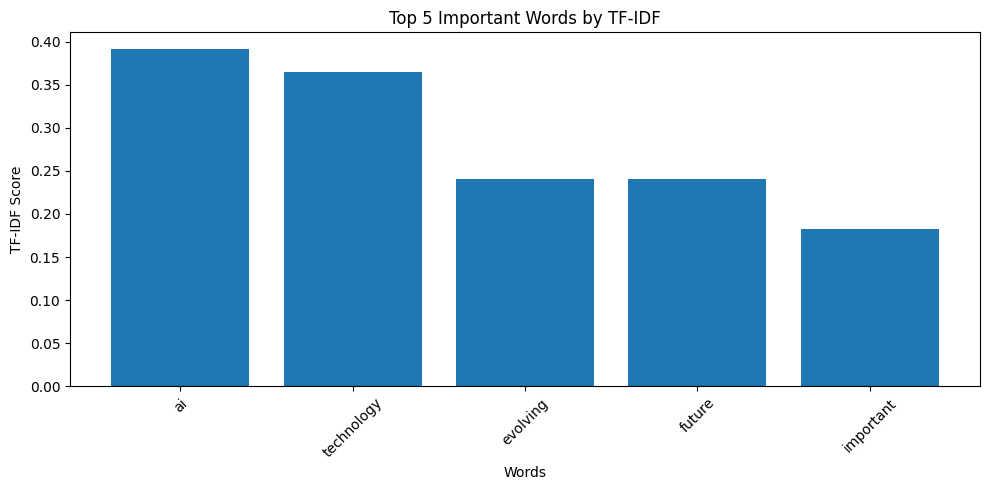

In [13]:
# TF-IDF Analysis of Given Documents
# Install if needed:
# pip install scikit-learn matplotlib pandas

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# -----------------------------------
# Step 1: Given Documents
# -----------------------------------

documents = [
    "AI is the future of technology",
    "AI and machine learning are important",
    "Technology is evolving with AI"
]

# -----------------------------------
# Step 2: Preprocess + TF-IDF
# lowercase + remove stopwords
# -----------------------------------

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

tfidf_matrix = vectorizer.fit_transform(documents)

# -----------------------------------
# Step 3: Get Vocabulary
# -----------------------------------

words = vectorizer.get_feature_names_out()

# -----------------------------------
# Step 4: Compute Average TF-IDF Score
# -----------------------------------

scores = tfidf_matrix.toarray()

avg_scores = scores.mean(axis=0)

# Create DataFrame
df = pd.DataFrame({
    "Word": words,
    "TF-IDF Score": avg_scores
})

# Sort descending
df = df.sort_values(by="TF-IDF Score", ascending=False)

# -----------------------------------
# Step 5: Extract Top 5 Important Words
# -----------------------------------

top5 = df.head(5)

print("Top 5 Important Words Based on TF-IDF:\n")
print(top5)

# -----------------------------------
# Step 6: Plot Bar Graph
# -----------------------------------

plt.figure(figsize=(10,5))
plt.bar(top5["Word"], top5["TF-IDF Score"])
plt.title("Top 5 Important Words by TF-IDF")
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


8)Rule-Based Sentiment Analyzer

In [15]:
# Rule-Based Sentiment Analyzer
# Install if needed:
# pip install nltk

import string
import nltk
from nltk.corpus import stopwords

# Download stopwords (run once)
nltk.download('stopwords')

# -----------------------------------
# Step 1: Input text from user
# -----------------------------------

text = input("Enter a sentence: ")

# -----------------------------------
# Step 2: Convert to lowercase
# -----------------------------------

text = text.lower()

# -----------------------------------
# Step 3: Remove punctuation
# -----------------------------------

text = text.translate(str.maketrans('', '', string.punctuation))

# -----------------------------------
# Step 4: Tokenize text into words
# -----------------------------------

words = text.split()

# Remove stopwords
stop_words = set(stopwords.words('english'))
words = [word for word in words if word not in stop_words]

# -----------------------------------
# Step 5: Create positive and negative word lists
# -----------------------------------

positive_words = [
    "good", "great", "excellent", "amazing", "happy",
    "love", "nice", "best", "wonderful", "fantastic",
    "awesome", "positive", "satisfied", "perfect"
]

negative_words = [
    "bad", "poor", "terrible", "awful", "hate",
    "worst", "sad", "angry", "disappointing",
    "negative", "slow", "boring", "ugly", "problem"
]

# -----------------------------------
# Step 6: Initialize counters
# -----------------------------------

positive_count = 0
negative_count = 0

# -----------------------------------
# Step 7: Check each word
# -----------------------------------

for word in words:
    if word in positive_words:
        positive_count += 1

    if word in negative_words:
        negative_count += 1

# -----------------------------------
# Step 8: Compare counts
# -----------------------------------

if positive_count > negative_count:
    sentiment = "Positive 😊"

elif negative_count > positive_count:
    sentiment = "Negative 😞"

else:
    sentiment = "Neutral 😐"

# -----------------------------------
# Step 9: Display Result
# -----------------------------------

print("\nProcessed Words:", words)
print("Positive Count:", positive_count)
print("Negative Count:", negative_count)
print("Final Sentiment:", sentiment)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Enter a sentence: how are you ?

Processed Words: []
Positive Count: 0
Negative Count: 0
Final Sentiment: Neutral 😐


9)Display the final sentiment result

In [16]:
# Sentiment Analysis using Machine Learning
# Objective: Build sentiment classifier using TF-IDF + Neural Network
# Install if needed:
# pip install pandas scikit-learn matplotlib

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------------------------------
# Step 1: Sample Dataset (Movie / Product Reviews)
# label: positive / negative
# -------------------------------------------------

data = {
    "Review": [
        "This movie was amazing and exciting",
        "The product quality is excellent",
        "I love this phone battery life",
        "Very disappointing and boring film",
        "Worst product I have ever bought",
        "The camera quality is fantastic",
        "Terrible customer service experience",
        "Absolutely wonderful performance",
        "The laptop is slow and useless",
        "Great value for money",
        "I hate this product",
        "Best purchase ever made",
        "The movie was dull and bad",
        "Highly recommend this item",
        "Waste of money and poor quality",
        "The service was excellent",
        "Awful experience and frustrating",
        "Superb features and design",
        "Not worth buying",
        "Very happy with the purchase"
    ],

    "Label": [
        "Positive", "Positive", "Positive",
        "Negative", "Negative", "Positive",
        "Negative", "Positive", "Negative",
        "Positive", "Negative", "Positive",
        "Negative", "Positive", "Negative",
        "Positive", "Negative", "Positive",
        "Negative", "Positive"
    ]
}

df = pd.DataFrame(data)

# -------------------------------------------------
# Step 2: Split Dataset
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    df["Review"],
    df["Label"],
    test_size=0.3,
    random_state=42
)

# -------------------------------------------------
# Step 3: Convert Text using TF-IDF
# -------------------------------------------------

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# -------------------------------------------------
# Step 4: Train Neural Network Model
# -------------------------------------------------

model = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

# -------------------------------------------------
# Step 5: Predict on Test Data
# -------------------------------------------------

y_pred = model.predict(X_test_tfidf)

# -------------------------------------------------
# Step 6: Compare Predictions with Actual Labels
# -------------------------------------------------

results = pd.DataFrame({
    "Review": X_test.values,
    "Actual Label": y_test.values,
    "Predicted Label": y_pred
})

print("Predictions vs Actual Labels:\n")
print(results)

# -------------------------------------------------
# Step 7: Accuracy & Report
# -------------------------------------------------

print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# -------------------------------------------------
# Step 8: Predict New Review
# -------------------------------------------------

new_review = ["This product is amazing and worth buying"]

new_tfidf = vectorizer.transform(new_review)

prediction = model.predict(new_tfidf)

print("\nNew Review Prediction:")
print(new_review[0], "->", prediction[0])


Predictions vs Actual Labels:

                                Review Actual Label Predicted Label
0  This movie was amazing and exciting     Positive        Negative
1           Superb features and design     Positive        Negative
2            The service was excellent     Positive        Negative
3     The product quality is excellent     Positive        Negative
4       The laptop is slow and useless     Negative        Negative
5      The camera quality is fantastic     Positive        Negative

Accuracy Score: 0.16666666666666666

Classification Report:

              precision    recall  f1-score   support

    Negative       0.17      1.00      0.29         1
    Positive       0.00      0.00      0.00         5

    accuracy                           0.17         6
   macro avg       0.08      0.50      0.14         6
weighted avg       0.03      0.17      0.05         6


Confusion Matrix:

[[1 0]
 [5 0]]

New Review Prediction:
This product is amazing and worth buying -> N

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


10)Rule-Based vs ML Comparison Study

In [17]:
# Rule-Based vs ML Sentiment Comparison Study
# Install if needed:
# pip install pandas nltk scikit-learn

import pandas as pd
import nltk
import string
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Download stopwords (run once)
nltk.download('stopwords')

# -------------------------------------------------
# Step 1: Sample Dataset
# -------------------------------------------------

data = {
    "Review": [
        "This product is amazing and excellent",
        "Worst item ever, very bad quality",
        "I love this phone",
        "Terrible experience and poor service",
        "Very happy with the purchase",
        "I hate this product",
        "Fantastic design and great performance",
        "Awful and disappointing",
        "Best product I bought",
        "Waste of money"
    ],

    "Label": [
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative"
    ]
}

df = pd.DataFrame(data)

# -------------------------------------------------
# Step 2: Split Dataset
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    df["Review"],
    df["Label"],
    test_size=0.3,
    random_state=42
)

# =================================================
# PART A: RULE-BASED SENTIMENT ANALYZER
# =================================================

positive_words = [
    "good", "great", "excellent", "amazing",
    "love", "happy", "fantastic", "best"
]

negative_words = [
    "bad", "worst", "terrible", "poor",
    "hate", "awful", "waste", "disappointing"
]

stop_words = set(stopwords.words('english'))

def rule_based_sentiment(text):

    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()
    words = [word for word in words if word not in stop_words]

    pos_count = 0
    neg_count = 0

    for word in words:
        if word in positive_words:
            pos_count += 1
        if word in negative_words:
            neg_count += 1

    if pos_count > neg_count:
        return "Positive"
    elif neg_count > pos_count:
        return "Negative"
    else:
        return "Neutral"

# Predict Rule-Based
rule_preds = [rule_based_sentiment(text) for text in X_test]

# Convert Neutral to Negative (for evaluation consistency)
rule_preds = ["Negative" if x == "Neutral" else x for x in rule_preds]

# =================================================
# PART B: MACHINE LEARNING MODEL
# =================================================

vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

ml_preds = model.predict(X_test_tfidf)

# =================================================
# Step 3: Evaluation Function
# =================================================

def evaluate_model(name, actual, predicted):
    print("\n", "="*40)
    print(name)
    print("="*40)

    print("Accuracy :", accuracy_score(actual, predicted))
    print("Precision:", precision_score(actual, predicted, pos_label="Positive"))
    print("Recall   :", recall_score(actual, predicted, pos_label="Positive"))

    print("\nClassification Report:\n")
    print(classification_report(actual, predicted))

# =================================================
# Step 4: Compare Both Methods
# =================================================

evaluate_model("Rule-Based Method", y_test, rule_preds)

evaluate_model("Machine Learning Method", y_test, ml_preds)

# =================================================
# Step 5: Final Comparison Table
# =================================================

comparison = pd.DataFrame({
    "Method": ["Rule-Based", "Machine Learning"],
    "Accuracy": [
        accuracy_score(y_test, rule_preds),
        accuracy_score(y_test, ml_preds)
    ],
    "Precision": [
        precision_score(y_test, rule_preds, pos_label="Positive"),
        precision_score(y_test, ml_preds, pos_label="Positive")
    ],
    "Recall": [
        recall_score(y_test, rule_preds, pos_label="Positive"),
        recall_score(y_test, ml_preds, pos_label="Positive")
    ]
})

print("\nFinal Comparison:\n")
print(comparison)



Rule-Based Method
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0

Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         2
    Positive       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Machine Learning Method
Accuracy : 0.3333333333333333
Precision: 0.3333333333333333
Recall   : 1.0

Classification Report:

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
    Positive       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3


Final Comparison:

             Method  Accuracy  Precision  Recall
0        Rule-Based  1.000000   1.000000     1.0
1  Machine Lea

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

11)Multilingual project

In [18]:
# ================================
# STEP 1: Install Required Libraries
# ================================
!pip install transformers torch -q


# ================================
# STEP 2: Import Libraries
# ================================
from transformers import pipeline


# ================================
# STEP 3: Load Multilingual Model
# ================================
print("Loading model... (this may take a few seconds)")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)
print("Model loaded successfully!\n")


# ================================
# STEP 4: Function to Convert Output
# ================================
def get_simple_sentiment(label):
    stars = int(label[0])  # Extract star rating

    if stars >= 4:
        return "Positive 😊"
    elif stars == 3:
        return "Neutral 😐"
    else:
        return "Negative 😠"


# ================================
# STEP 5: Test with Sample Inputs
# ================================
print("Testing with sample Indian language sentences:\n")

sample_texts = [
    "यह बहुत अच्छा है",        # Hindi Positive
    "यह बहुत खराब है",        # Hindi Negative
    "ఈ సినిమా చాలా బాగుంది",  # Telugu Positive
    "இந்த படம் மோசமாக உள்ளது", # Tamil Negative
    "This product is amazing"  # English Positive
]

for text in sample_texts:
    result = sentiment_pipeline(text)
    simple_sentiment = get_simple_sentiment(result[0]['label'])

    print(f"Text: {text}")
    print(f"Predicted Sentiment: {simple_sentiment}")
    print("-" * 50)


# ================================
# STEP 6: User Input Mode
# ================================
print("\nEnter your own text for sentiment analysis!")
print("Type 'exit' to stop.\n")

while True:
    user_input = input("Enter text: ")

    if user_input.lower() == "exit":
        print("Program ended.")
        break

    result = sentiment_pipeline(user_input)
    simple_sentiment = get_simple_sentiment(result[0]['label'])

    print(f"Sentiment: {simple_sentiment}\n")

Loading model... (this may take a few seconds)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model loaded successfully!

Testing with sample Indian language sentences:

Text: यह बहुत अच्छा है
Predicted Sentiment: Positive 😊
--------------------------------------------------
Text: यह बहुत खराब है
Predicted Sentiment: Negative 😠
--------------------------------------------------
Text: ఈ సినిమా చాలా బాగుంది
Predicted Sentiment: Negative 😠
--------------------------------------------------
Text: இந்த படம் மோசமாக உள்ளது
Predicted Sentiment: Negative 😠
--------------------------------------------------
Text: This product is amazing
Predicted Sentiment: Positive 😊
--------------------------------------------------

Enter your own text for sentiment analysis!
Type 'exit' to stop.

Enter text: how are you ?
Sentiment: Positive 😊

Enter text: exit
Program ended.


12)Develop a system that automatically classifies customer complaints into predefined categories

In [19]:
# =========================================
# STEP 1: Install Required Libraries
# =========================================
!pip install scikit-learn pandas -q


# =========================================
# STEP 2: Import Libraries
# =========================================
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


# =========================================
# STEP 3: Sample Dataset (You can expand this)
# =========================================
data = {
    "text": [
        "I was charged extra on my bill",
        "My internet is not working",
        "The service was very slow",
        "Billing amount is incorrect",
        "Customer support did not respond",
        "App keeps crashing again and again",
        "Wrong charges applied to my account",
        "Network connectivity issue",
        "Staff behavior was rude",
        "Payment deducted but service not activated"
    ],
    "label": [
        "billing",
        "technical",
        "service",
        "billing",
        "service",
        "technical",
        "billing",
        "technical",
        "service",
        "billing"
    ]
}

df = pd.DataFrame(data)


# =========================================
# STEP 4: Text Preprocessing Function
# =========================================
def preprocess(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
    tokens = text.split()  # tokenize
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(preprocess)


# =========================================
# STEP 5: Convert Text to TF-IDF Features
# =========================================
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]


# =========================================
# STEP 6: Train Model (Logistic Regression)
# =========================================
model = LogisticRegression()
model.fit(X, y)

print("Model trained successfully!\n")


# =========================================
# STEP 7: Department Mapping
# =========================================
department_map = {
    "billing": "Finance Team",
    "service": "Customer Service Team",
    "technical": "Technical Support Team"
}


# =========================================
# STEP 8: Prediction Function
# =========================================
def predict_complaint(text):
    clean = preprocess(text)
    vec = vectorizer.transform([clean])

    prediction = model.predict(vec)[0]
    department = department_map[prediction]

    return prediction, department


# =========================================
# STEP 9: Test with Sample Input
# =========================================
test_text = "I am facing issue with my payment and billing"
category, dept = predict_complaint(test_text)

print("Complaint:", test_text)
print("Predicted Category:", category)
print("Assigned Department:", dept)


# =========================================
# STEP 10: User Input Mode
# =========================================
print("\nEnter your complaint (type 'exit' to stop):\n")

while True:
    user_input = input("Enter complaint: ")

    if user_input.lower() == "exit":
        print("Program ended.")
        break

    category, dept = predict_complaint(user_input)

    print("Category:", category)
    print("Assigned Department:", dept)
    print("-" * 40)

Model trained successfully!

Complaint: I am facing issue with my payment and billing
Predicted Category: billing
Assigned Department: Finance Team

Enter your complaint (type 'exit' to stop):

Enter complaint: i am facing issue with payment
Category: billing
Assigned Department: Finance Team
----------------------------------------
Enter complaint: exit
Program ended.


13)Smart Complaint Deduplication System (CRM Optimization)


========== FINAL REPORT ==========

Total Complaints: 10
Number of Issue Groups: 10 

Top Issues (by group size):

Group
0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: count, dtype: int64 

Group Keywords & Summary:

Group 0:
 Keywords: ['working', 'internet', 'wifi']
 Summary: working internet wifi

Group 1:
 Keywords: ['morning', 'internet', 'wrong']
 Summary: morning internet wrong

Group 2:
 Keywords: ['wifi', 'connection', 'working']
 Summary: wifi connection working

Group 3:
 Keywords: ['wrong', 'charged', 'wifi']
 Summary: wrong charged wifi

Group 4:
 Keywords: ['billing', 'incorrect', 'wrong']
 Summary: billing incorrect wrong

Group 5:
 Keywords: ['service', 'activated', 'deducted']
 Summary: service activated deducted

Group 6:
 Keywords: ['crashing', 'app', 'frequently']
 Summary: crashing app frequently

Group 7:
 Keywords: ['crashes', 'application', 'login']
 Summary: crashes application login

Group 8:
 Keywords: ['responding', 'customer', 

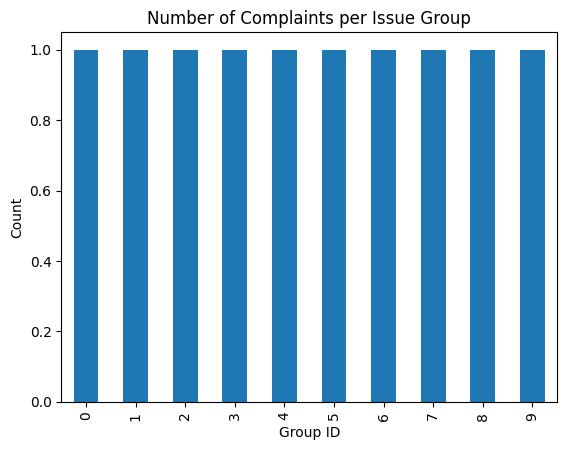

In [20]:
# =========================================
# STEP 1: Install Required Libraries
# =========================================
!pip install pandas scikit-learn matplotlib -q


# =========================================
# STEP 2: Import Libraries
# =========================================
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt


# =========================================
# STEP 3: Sample Dataset (You can replace this)
# =========================================
complaints = [
    "Internet not working",
    "No internet since morning",
    "Wifi connection is down",
    "Wrong bill charged",
    "Incorrect billing amount",
    "Payment deducted but service not activated",
    "App is crashing frequently",
    "Application crashes on login",
    "Customer support not responding",
    "No response from support team"
]

df = pd.DataFrame({"Complaint": complaints})


# =========================================
# STEP 4: Preprocessing Function
# =========================================
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS]
    return " ".join(tokens)

df["Clean"] = df["Complaint"].apply(preprocess)


# =========================================
# STEP 5: TF-IDF Vectorization
# =========================================
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["Clean"])


# =========================================
# STEP 6: Cosine Similarity Matrix
# =========================================
similarity_matrix = cosine_similarity(X)


# =========================================
# STEP 7: Grouping Similar Complaints
# =========================================
threshold = 0.5  # You can tune this
group_ids = [-1] * len(df)
group_id = 0

for i in range(len(df)):
    if group_ids[i] == -1:
        group_ids[i] = group_id
        for j in range(i + 1, len(df)):
            if similarity_matrix[i][j] >= threshold:
                group_ids[j] = group_id
        group_id += 1

df["Group"] = group_ids


# =========================================
# STEP 8: Count Complaints per Group
# =========================================
group_counts = df["Group"].value_counts().sort_index()


# =========================================
# STEP 9: Extract Keywords per Group
# =========================================
feature_names = vectorizer.get_feature_names_out()

group_keywords = {}

for g in df["Group"].unique():
    group_texts = df[df["Group"] == g]["Clean"]
    group_vec = vectorizer.transform(group_texts)
    mean_tfidf = np.mean(group_vec.toarray(), axis=0)

    top_indices = mean_tfidf.argsort()[-3:][::-1]
    keywords = [feature_names[i] for i in top_indices]

    group_keywords[g] = keywords


# =========================================
# STEP 10: Generate Summary per Group
# =========================================
group_summary = {}

for g, words in group_keywords.items():
    summary = " ".join(words)
    group_summary[g] = summary


# =========================================
# STEP 11: Final Report
# =========================================
print("\n========== FINAL REPORT ==========\n")

print("Total Complaints:", len(df))
print("Number of Issue Groups:", df["Group"].nunique(), "\n")

print("Top Issues (by group size):\n")
print(group_counts, "\n")

print("Group Keywords & Summary:\n")
for g in group_keywords:
    print(f"Group {g}:")
    print(" Keywords:", group_keywords[g])
    print(" Summary:", group_summary[g])
    print()


# =========================================
# STEP 12: Display Complaint vs Group Table
# =========================================
print("\nComplaint Grouping:\n")
print(df[["Complaint", "Group"]])


# =========================================
# STEP 13: Visualization (Chart)
# =========================================
plt.figure()
group_counts.plot(kind='bar')
plt.title("Number of Complaints per Issue Group")
plt.xlabel("Group ID")
plt.ylabel("Count")
plt.show()

14)

15)Customer Ticket Priority Prediction System

In [21]:
# =========================================
# STEP 1: Install Required Libraries
# =========================================
!pip install pandas scikit-learn -q


# =========================================
# STEP 2: Import Libraries
# =========================================
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# =========================================
# STEP 3: Sample Dataset
# =========================================
data = {
    "Complaint": [
        "My service has been down for 2 days",
        "Internet is not working at all",
        "Need help updating profile",
        "Unable to login to my account",
        "Internet is slow sometimes",
        "App crashes occasionally",
        "Billing issue needs to be fixed urgently",
        "How to change my password",
        "No network since morning",
        "Feature request for new update"
    ],
    "Priority": [
        "High",
        "High",
        "Low",
        "Medium",
        "Medium",
        "Medium",
        "High",
        "Low",
        "High",
        "Low"
    ]
}

df = pd.DataFrame(data)


# =========================================
# STEP 4: Text Preprocessing
# =========================================
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in ENGLISH_STOP_WORDS]
    return " ".join(tokens)

df["Clean"] = df["Complaint"].apply(preprocess)


# =========================================
# STEP 5: Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    df["Clean"], df["Priority"], test_size=0.2, random_state=42
)


# =========================================
# STEP 6: TF-IDF Vectorization
# =========================================
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


# =========================================
# STEP 7: Train Model (Logistic Regression)
# =========================================
model = LogisticRegression()
model.fit(X_train_vec, y_train)


# =========================================
# STEP 8: Model Evaluation
# =========================================
y_pred = model.predict(X_test_vec)

print("\n===== MODEL EVALUATION =====\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# =========================================
# STEP 9: Prediction Function
# =========================================
def predict_priority(text):
    clean = preprocess(text)
    vec = vectorizer.transform([clean])
    prediction = model.predict(vec)[0]
    return prediction


# =========================================
# STEP 10: Test Example
# =========================================
test_text = "My internet has not been working for 3 days"
print("\nTest Complaint:", test_text)
print("Predicted Priority:", predict_priority(test_text))


# =========================================
# STEP 11: User Input Mode
# =========================================
print("\nEnter complaint (type 'exit' to stop):\n")

while True:
    user_input = input("Enter complaint: ")

    if user_input.lower() == "exit":
        print("Program ended.")
        break

    result = predict_priority(user_input)
    print("Predicted Priority:", result)
    print("-" * 40)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_


===== MODEL EVALUATION =====

Accuracy: 0.0

Classification Report:

              precision    recall  f1-score   support

        High       0.00      0.00      0.00       2.0
      Medium       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


Test Complaint: My internet has not been working for 3 days
Predicted Priority: Medium

Enter complaint (type 'exit' to stop):

Enter complaint: my internet doesnt work
Predicted Priority: Medium
----------------------------------------
Enter complaint: stop
Predicted Priority: Medium
----------------------------------------
Enter complaint: exit
Program ended.


16)Why Are Customers Unhappy?

In [22]:
# =========================================
# STEP 1: Install Required Libraries
# =========================================
!pip install pandas scikit-learn nltk -q


# =========================================
# STEP 2: Import Libraries
# =========================================
import pandas as pd
import re
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))


# =========================================
# STEP 3: Sample Customer Reviews (Replace with real data)
# =========================================
reviews = [
    "App crashes frequently and does not open",
    "Very slow performance and lagging issues",
    "Payment failed but money deducted",
    "Customer support is not responding",
    "App keeps freezing again and again",
    "Billing issue and wrong charges applied",
    "Login problem and authentication error",
    "Too many bugs in the application",
    "Service is very slow and frustrating",
    "Refund not received after payment failure"
]

df = pd.DataFrame({"Review": reviews})


# =========================================
# STEP 4: Text Preprocessing
# =========================================
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["Clean"] = df["Review"].apply(preprocess)


# =========================================
# STEP 5: Vectorization (Bag of Words)
# =========================================
vectorizer = CountVectorizer(max_df=0.9, min_df=1)
X = vectorizer.fit_transform(df["Clean"])


# =========================================
# STEP 6: Apply LDA Model
# =========================================
num_topics = 3  # You can change this
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(X)


# =========================================
# STEP 7: Extract Top Keywords per Topic
# =========================================
feature_names = vectorizer.get_feature_names_out()

def get_topics(model, feature_names, num_words=5):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[-num_words:][::-1]
        words = [feature_names[i] for i in top_words_idx]
        topics[topic_idx] = words
    return topics

topics = get_topics(lda, feature_names)


# =========================================
# STEP 8: Display Topics
# =========================================
print("\n===== DISCOVERED TOPICS =====\n")

for topic, words in topics.items():
    print(f"Topic {topic}: {words}")


# =========================================
# STEP 9: Assign Topic to Each Review
# =========================================
topic_values = lda.transform(X)
df["Topic"] = topic_values.argmax(axis=1)


# =========================================
# STEP 10: Interpret Topics (Business Meaning)
# =========================================
print("\n===== REVIEW + TOPIC =====\n")
print(df[["Review", "Topic"]])


# =========================================
# STEP 11: Topic Summary (Business Insight)
# =========================================
print("\n===== BUSINESS INSIGHTS =====\n")

for topic, words in topics.items():
    summary = " ".join(words)
    print(f"Topic {topic} Summary: {summary}")


===== DISCOVERED TOPICS =====

Topic 0: ['payment', 'problem', 'authentication', 'error', 'login']
Topic 1: ['app', 'open', 'frequently', 'crashes', 'failed']
Topic 2: ['slow', 'wrong', 'charges', 'issue', 'applied']

===== REVIEW + TOPIC =====

                                      Review  Topic
0   App crashes frequently and does not open      1
1   Very slow performance and lagging issues      2
2          Payment failed but money deducted      1
3         Customer support is not responding      0
4         App keeps freezing again and again      1
5    Billing issue and wrong charges applied      2
6     Login problem and authentication error      0
7           Too many bugs in the application      2
8       Service is very slow and frustrating      1
9  Refund not received after payment failure      0

===== BUSINESS INSIGHTS =====

Topic 0 Summary: payment problem authentication error login
Topic 1 Summary: app open frequently crashes failed
Topic 2 Summary: slow wrong charges i

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


17)Detect the Next Big Crisis Before It Hits


===== TREND ANALYSIS =====

Topic    0  1  2
Month           
2024-01  1  2  0
2024-02  1  0  2
2024-03  3  0  1

===== EMERGING ISSUES =====

⚠️ Topic 0 is increasing!
Keywords: ['app', 'network', 'issue', 'slow']
Summary: app network issue slow

⚠️ Topic 2 is increasing!
Keywords: ['service', 'deducted', 'money', 'many']
Summary: service deducted money many



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


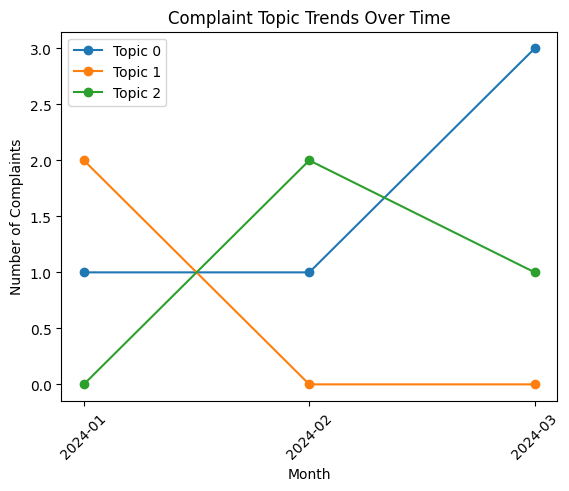

In [23]:
# =========================================
# STEP 1: Install Libraries
# =========================================
!pip install pandas scikit-learn nltk matplotlib -q


# =========================================
# STEP 2: Import Libraries
# =========================================
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


# =========================================
# STEP 3: Sample Dataset with Time (IMPORTANT)
# =========================================
data = {
    "Date": [
        "2024-01-01","2024-01-05","2024-01-10",
        "2024-02-02","2024-02-10","2024-02-15",
        "2024-03-01","2024-03-05","2024-03-10",
        "2024-03-15"
    ],
    "Complaint": [
        "Internet not working",
        "Wifi is down",
        "Slow network issue",
        "Payment failed",
        "Money deducted but no service",
        "Billing problem",
        "App crashing frequently",
        "Application freezes",
        "App crashes again",
        "Too many bugs in app"
    ]
}

df = pd.DataFrame(data)
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")


# =========================================
# STEP 4: Preprocessing
# =========================================
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

df["Clean"] = df["Complaint"].apply(preprocess)


# =========================================
# STEP 5: Vectorization
# =========================================
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["Clean"])


# =========================================
# STEP 6: LDA Topic Modeling
# =========================================
num_topics = 3
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(X)


# =========================================
# STEP 7: Assign Topic to Each Complaint
# =========================================
topic_values = lda.transform(X)
df["Topic"] = topic_values.argmax(axis=1)


# =========================================
# STEP 8: Topic Frequency Over Time
# =========================================
trend = df.groupby(["Month", "Topic"]).size().unstack(fill_value=0)


# =========================================
# STEP 9: Identify Emerging Topics
# =========================================
print("\n===== TREND ANALYSIS =====\n")
print(trend)

# Detect increasing trend (simple logic)
emerging_topics = []

for topic in trend.columns:
    values = trend[topic].values
    if len(values) >= 2 and values[-1] > values[0]:
        emerging_topics.append(topic)


# =========================================
# STEP 10: Extract Keywords per Topic
# =========================================
feature_names = vectorizer.get_feature_names_out()

def get_topics(model, feature_names, n_words=4):
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[-n_words:][::-1]
        words = [feature_names[i] for i in top_idx]
        topics[idx] = words
    return topics

topics = get_topics(lda, feature_names)


# =========================================
# STEP 11: Display Emerging Issues
# =========================================
print("\n===== EMERGING ISSUES =====\n")

for t in emerging_topics:
    print(f"⚠️ Topic {t} is increasing!")
    print("Keywords:", topics[t])
    print("Summary:", " ".join(topics[t]))
    print()


# =========================================
# STEP 12: Visualization
# =========================================
plt.figure()

for topic in trend.columns:
    plt.plot(trend.index.astype(str), trend[topic], marker='o', label=f"Topic {topic}")

plt.title("Complaint Topic Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.legend()
plt.xticks(rotation=45)
plt.show()